E-Commerce Sales Data Analysis and Exploratory Data Analysis (EDA)

This project performs Exploratory Data Analysis on an e-commerce
dataset to understand sales, products, customers, revenue,
payment methods, order status, referral sources, and trends.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_excel(r"C:\Users\anish\Downloads\Dataset for Data Analytics.xlsx")

In [3]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [5]:
df.shape

(1200, 14)

In [6]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [8]:
df.dtypes

OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [ ]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [12]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [14]:
df.duplicated().sum()

0

In [16]:
df["OrderID"].unique()

array(['ORD200000', 'ORD200001', 'ORD200002', ..., 'ORD201197',
       'ORD201198', 'ORD201199'], dtype=object)

In [17]:
len(df["OrderID"].unique())

1200

In [20]:
len(df["TrackingNumber"].unique())

1200

In [22]:
df['Product'].unique()

array(['Monitor', 'Phone', 'Tablet', 'Chair', 'Printer', 'Laptop', 'Desk'],
      dtype=object)

In [23]:
df['PaymentMethod'].unique()

array(['Debit Card', 'Online', 'Credit Card', 'Gift Card', 'Cash'],
      dtype=object)

In [24]:
df['OrderStatus'].unique()

array(['Shipped', 'Cancelled', 'Returned', 'Delivered', 'Pending'],
      dtype=object)

In [25]:
df['CouponCode'].unique()

array(['SAVE10', 'FREESHIP', 'NONE', 'WINTER15'], dtype=object)

In [26]:
df['ReferralSource'].unique()

array(['Instagram', 'Referral', 'Email', 'Facebook', 'Google'],
      dtype=object)

In [27]:
numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

df[numeric_cols].describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


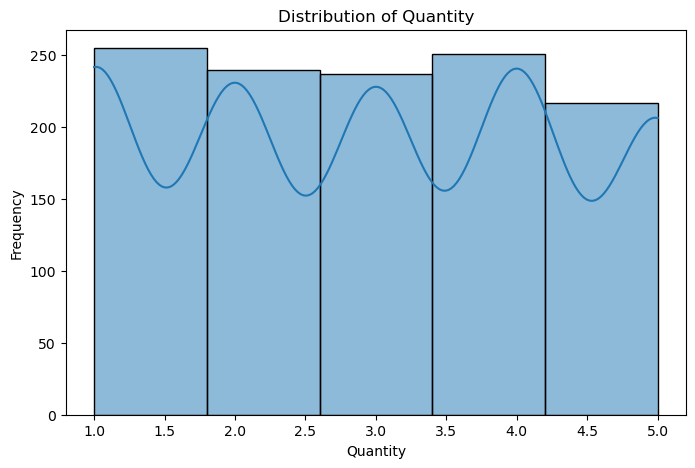

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(df['Quantity'], bins=5, kde=True)

plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')

plt.show()

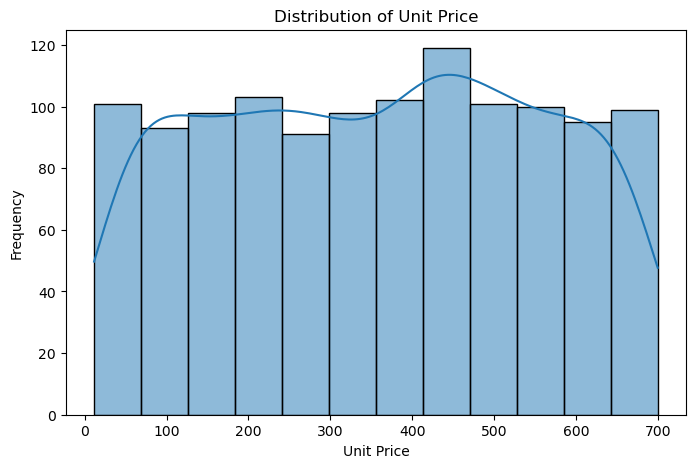

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df['UnitPrice'], kde=True)

plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')

plt.show()

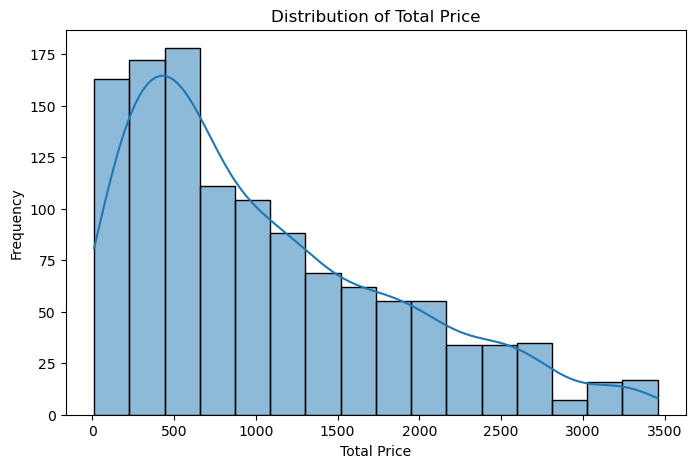

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(df['TotalPrice'], kde=True)

plt.title('Distribution of Total Price')
plt.xlabel('Total Price')
plt.ylabel('Frequency')

plt.show()

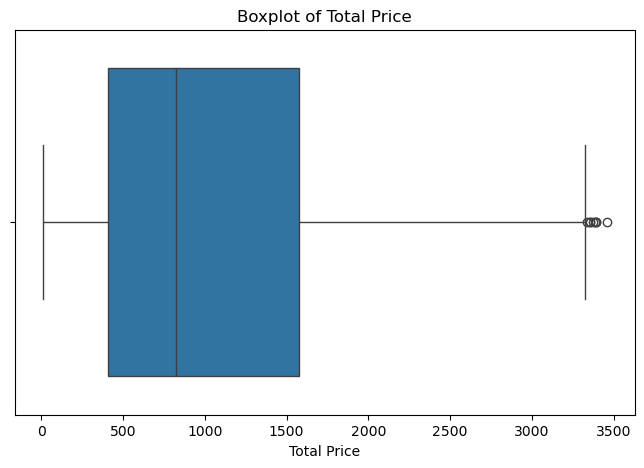

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['TotalPrice'])

plt.title('Boxplot of Total Price')
plt.xlabel('Total Price')

plt.show()

In [32]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['TotalPrice'] < lower_bound) |
    (df['TotalPrice'] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))

Lower Bound: -1341.4125
Upper Bound: 3330.4075
Number of Outliers: 8


In [33]:
product_orders = df['Product'].value_counts()

product_orders

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

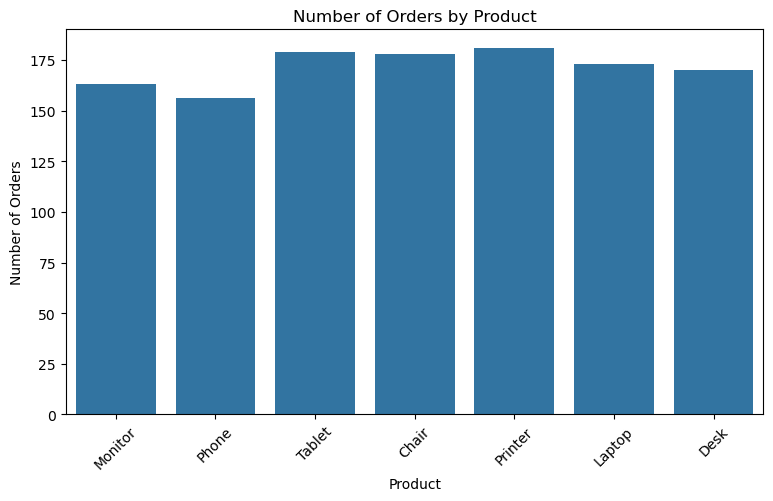

In [34]:
plt.figure(figsize=(9,5))

sns.countplot(data=df, x='Product')

plt.title('Number of Orders by Product')
plt.xlabel('Product')
plt.ylabel('Number of Orders')

plt.xticks(rotation=45)

plt.show()

In [36]:
product_quantity = (
    df.groupby('Product')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

product_quantity

Product
Chair      562
Printer    542
Laptop     535
Desk       508
Tablet     497
Monitor    480
Phone      411
Name: Quantity, dtype: int64

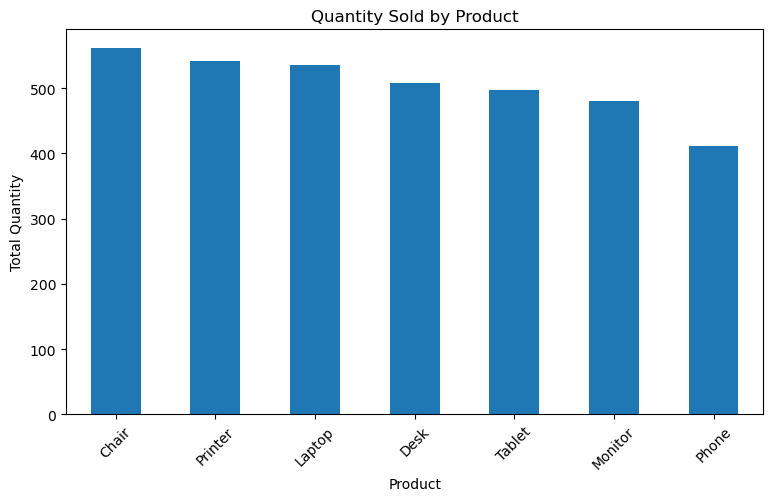

In [37]:
product_quantity.plot(
    kind='bar',
    figsize=(9,5)
)

plt.title('Quantity Sold by Product')
plt.xlabel('Product')
plt.ylabel('Total Quantity')

plt.xticks(rotation=45)

plt.show()

In [38]:
product_revenue = (
    df.groupby('Product')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
)

product_revenue

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

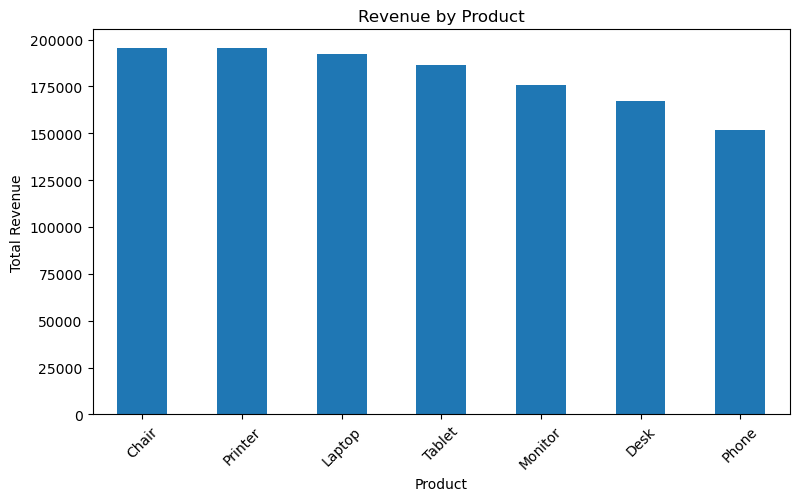

In [39]:
plt.figure(figsize=(9,5))

product_revenue.plot(kind='bar')

plt.title('Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)

plt.show()

In [40]:
df.groupby('Product')['TotalPrice'].mean().sort_values(ascending=False)

Product
Laptop     1110.558150
Chair      1098.989382
Printer    1080.732652
Monitor    1077.616012
Tablet     1042.284637
Desk        985.058412
Phone       972.579423
Name: TotalPrice, dtype: float64

In [41]:
df['PaymentMethod'].value_counts()


PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

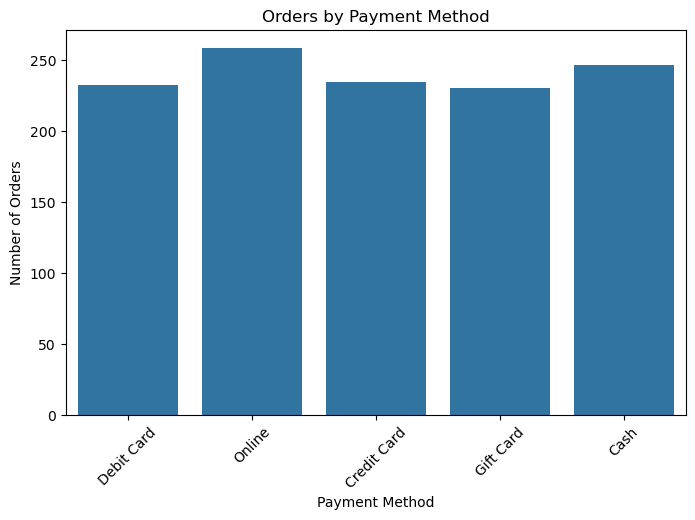

In [42]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='PaymentMethod')

plt.title('Orders by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')

plt.xticks(rotation=45)

plt.show()

In [43]:
payment_revenue = (
    df.groupby('PaymentMethod')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
)

payment_revenue

PaymentMethod
Credit Card    263847.63
Online         262442.94
Cash           259786.29
Gift Card      246323.92
Debit Card     232361.18
Name: TotalPrice, dtype: float64

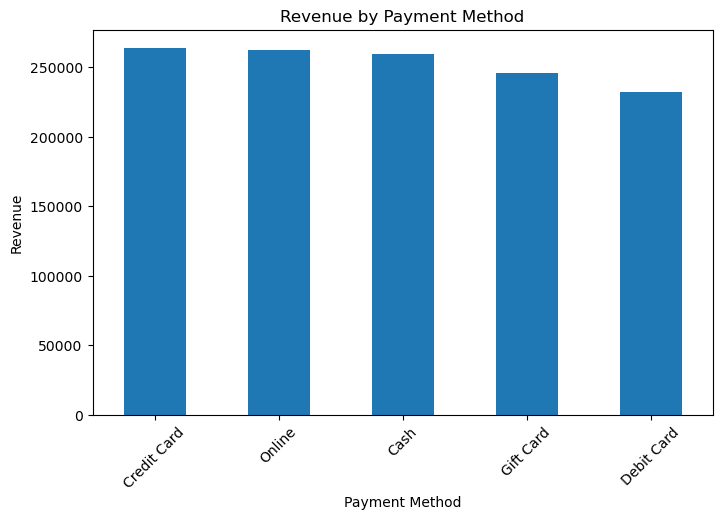

In [44]:
payment_revenue.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

In [45]:
df['OrderStatus'].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

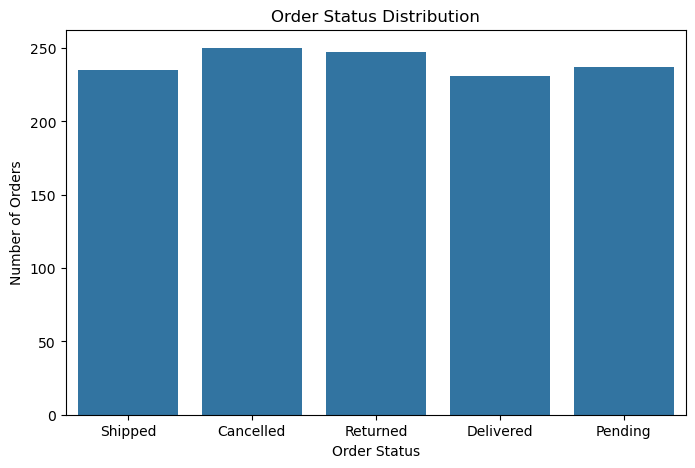

In [46]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='OrderStatus')

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')

plt.show()

In [47]:
status_revenue = (
    df.groupby('OrderStatus')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
)

status_revenue

OrderStatus
Cancelled    276396.21
Pending      256328.15
Shipped      246159.58
Returned     243277.70
Delivered    242600.32
Name: TotalPrice, dtype: float64

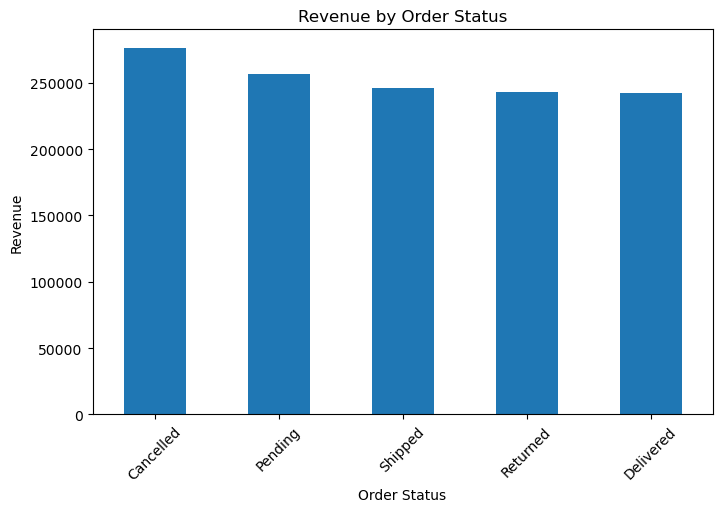

In [48]:
status_revenue.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Revenue by Order Status')
plt.xlabel('Order Status')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

In [49]:
df['ReferralSource'].value_counts()

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

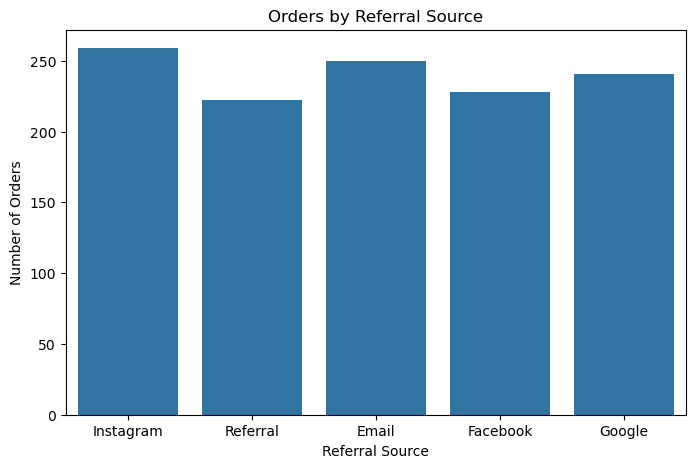

In [51]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='ReferralSource')

plt.title('Orders by Referral Source')
plt.xlabel('Referral Source')
plt.ylabel('Number of Orders')

plt.show()

In [52]:
referral_revenue = (
    df.groupby('ReferralSource')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
)

referral_revenue

ReferralSource
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: TotalPrice, dtype: float64

In [53]:
referral_revenue = (
    df.groupby('ReferralSource')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
)

referral_revenue

ReferralSource
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: TotalPrice, dtype: float64

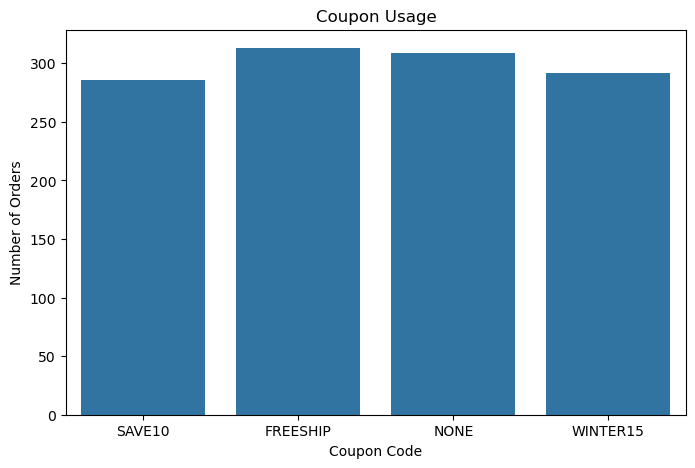

In [54]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='CouponCode')

plt.title('Coupon Usage')
plt.xlabel('Coupon Code')
plt.ylabel('Number of Orders')

plt.show()

In [55]:
coupon_revenue = (
    df.groupby('CouponCode')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
)

coupon_revenue

CouponCode
FREESHIP    335036.99
NONE        322401.41
SAVE10      304840.02
WINTER15    302483.54
Name: TotalPrice, dtype: float64

In [56]:
df['Date'].dtype

dtype('<M8[ns]')

In [57]:
df['Year'] = df['Date'].dt.year

In [59]:
yearly_orders = df.groupby('Year')['OrderID'].count()

yearly_orders

Year
2023    510
2024    459
2025    231
Name: OrderID, dtype: int64

In [60]:

yearly_revenue = df.groupby('Year')['TotalPrice'].sum()

yearly_revenue

Year
2023    552643.24
2024    480235.87
2025    231882.85
Name: TotalPrice, dtype: float64

In [61]:
monthly_revenue = (
    df.groupby(df['Date'].dt.to_period('M'))['TotalPrice']
    .sum()
)

monthly_revenue

Date
2023-01    56685.75
2023-02    40117.66
2023-03    48609.37
2023-04    27751.71
2023-05    63836.84
2023-06    49500.19
2023-07    42820.66
2023-08    54352.14
2023-09    29526.67
2023-10    52607.85
2023-11    43079.67
2023-12    43754.73
2024-01    38528.08
2024-02    36909.57
2024-03    36030.90
2024-04    49613.14
2024-05    27909.11
2024-06    68068.54
2024-07    42963.98
2024-08    31991.07
2024-09    39794.98
2024-10    37226.97
2024-11    32413.76
2024-12    38785.77
2025-01    29099.40
2025-02    35317.55
2025-03    39200.66
2025-04    31821.20
2025-05    43396.64
2025-06    53047.40
Freq: M, Name: TotalPrice, dtype: float64

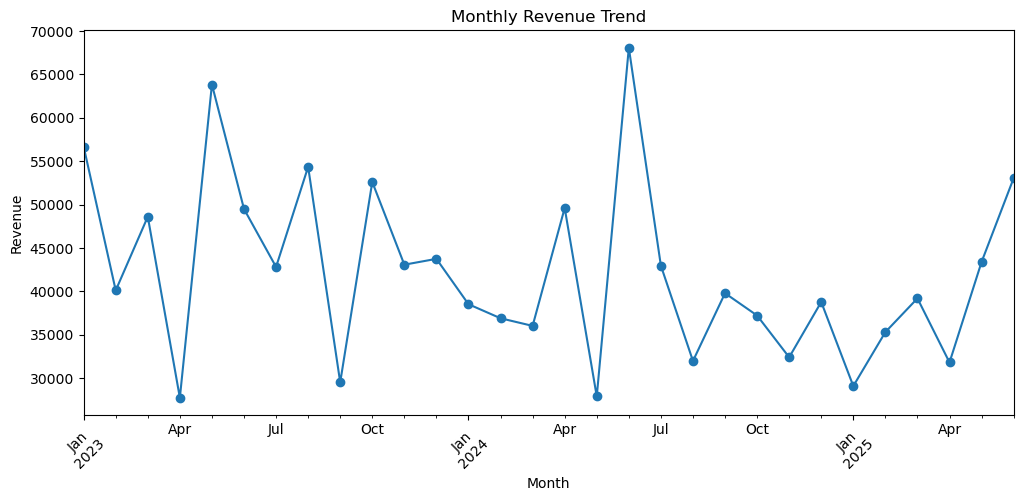

In [62]:
plt.figure(figsize=(12,5))

monthly_revenue.plot(marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

In [63]:
df['CustomerID'].nunique()

1189

In [64]:
customer_orders = (
    df.groupby('CustomerID')['OrderID']
    .count()
    .sort_values(ascending=False)
)

customer_orders.head(10)

CustomerID
C35852    2
C94569    2
C97593    2
C14847    2
C91155    2
C98474    2
C70659    2
C38840    2
C46651    2
C56969    2
Name: OrderID, dtype: int64

In [65]:
top_customers = (
    df.groupby('CustomerID')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

CustomerID
C38840    5723.23
C57276    3456.40
C67260    3390.80
C13877    3384.90
C18404    3370.20
C16775    3353.75
C65986    3352.40
C47778    3334.00
C59183    3322.55
C25276    3313.90
Name: TotalPrice, dtype: float64

In [66]:
df.nlargest(
    10,
    'TotalPrice'
)[
    ['OrderID', 'CustomerID', 'Product',
     'Quantity', 'UnitPrice', 'TotalPrice']
]

,OrderID,CustomerID,Product,Quantity,UnitPrice,TotalPrice
789,ORD200789,C57276,Tablet,5,691.28,3456.40
1122,ORD201122,C38840,Monitor,5,678.19,3390.95
632,ORD200632,C67260,Laptop,5,678.16,3390.80
469,ORD200469,C13877,Chair,5,676.98,3384.90
328,ORD200328,C18404,Tablet,5,674.04,3370.20
107,ORD200107,C16775,Printer,5,670.75,3353.75
326,ORD200326,C65986,Laptop,5,670.48,3352.40
1065,ORD201065,C47778,Printer,5,666.80,3334.00
1031,ORD201031,C59183,Phone,5,664.51,3322.55
463,ORD200463,C25276,Laptop,5,662.78,3313.90


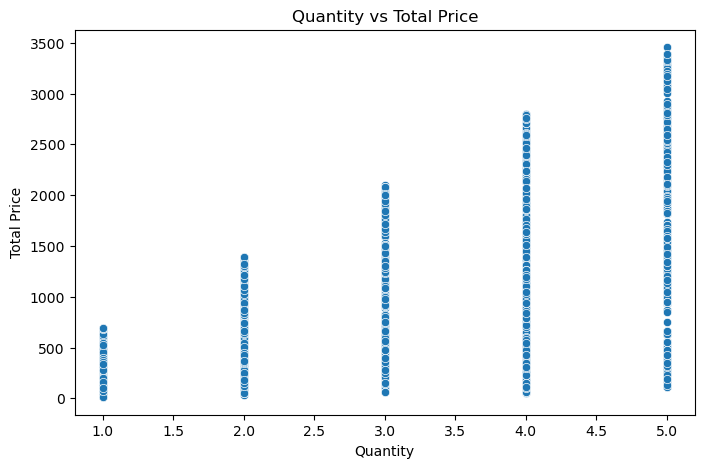

In [67]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Quantity',
    y='TotalPrice'
)

plt.title('Quantity vs Total Price')
plt.xlabel('Quantity')
plt.ylabel('Total Price')

plt.show()

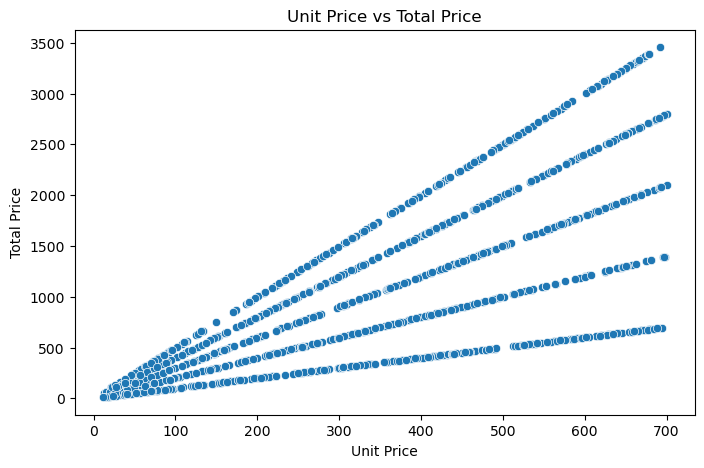

In [69]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='UnitPrice',
    y='TotalPrice'
)

plt.title('Unit Price vs Total Price')
plt.xlabel('Unit Price')
plt.ylabel('Total Price')

plt.show()

In [70]:
numeric_cols = [
    'Quantity',
    'UnitPrice',
    'ItemsInCart',
    'TotalPrice'
]

corr = df[numeric_cols].corr()

corr

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


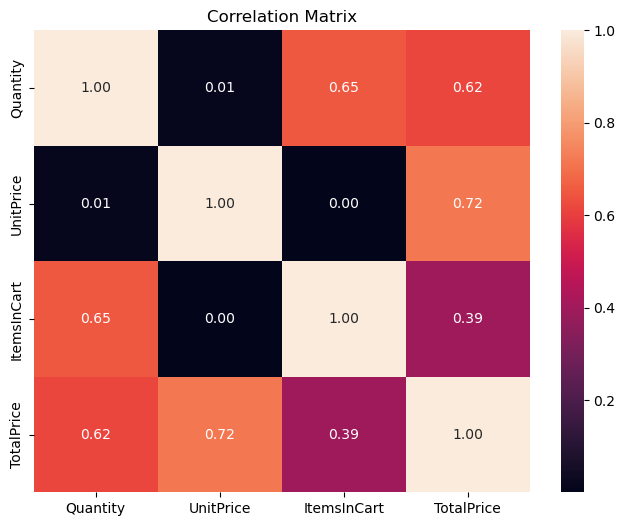

In [71]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

In [81]:
calculated_total = df['Quantity'] * df['UnitPrice']

difference = (df['TotalPrice'] - calculated_total).abs()

print("Maximum Difference:", difference.max())
print("Incorrect Rows:", (difference > 0.01).sum())

Maximum Difference: 4.547473508864641e-13
Incorrect Rows: 0


In [76]:
product_summary = df.groupby('Product').agg(
    Total_Orders=('OrderID', 'count'),
    Total_Quantity=('Quantity', 'sum'),
    Total_Revenue=('TotalPrice', 'sum'),
    Average_Order_Value=('TotalPrice', 'mean'),
    Average_Unit_Price=('UnitPrice', 'mean')
).sort_values(
    'Total_Revenue',
    ascending=False
)

product_summary.round(2)

,Total_Orders,Total_Quantity,Total_Revenue,Average_Order_Value,Average_Unit_Price
Product,,,,,
Chair,178,562,195620.11,1098.99,355.66
Printer,181,542,195612.61,1080.73,351.71
Laptop,173,535,192126.56,1110.56,357.71
Tablet,179,497,186568.95,1042.28,367.68
Monitor,163,480,175651.41,1077.62,358.66
Desk,170,508,167459.93,985.06,329.61
Phone,156,411,151722.39,972.58,375.22


 Key Business Insights

1. The dataset contains 1,200 orders and 14 original columns.

2. The dataset contains 1,189 unique customers, indicating that
   a small number of customers placed multiple orders.

3. Printer has the highest number of orders with 181 orders.

4. Chair has the highest total quantity sold with 562 units.

5. Chair generates the highest revenue at 195,620.11, closely
   followed by Printer at 195,612.61.

6. Laptop has the highest average order value at approximately
   1,110.56.

7. Online is the most frequently used payment method with
   258 orders, while Credit Card generates the highest revenue.

8. Cancelled orders are the largest order-status category with
   250 orders and also account for the highest revenue among
   order-status categories.

9. Instagram is the leading referral source with 259 orders
   and generates the highest revenue among referral sources.

10. FREESHIP is the most frequently used coupon code with
    313 orders and also contributes the highest total revenue
    among coupon categories.

11. The highest monthly revenue was recorded in June 2024,
    with revenue of approximately 68,068.54.

12. UnitPrice has a stronger positive correlation with TotalPrice
    (0.717) than Quantity does (0.615).

13. TotalPrice is correctly calculated as Quantity multiplied by
    UnitPrice for all records.

14. Eight potential outliers were identified in TotalPrice using
    the IQR method. These were retained because they may represent
    genuine high-value orders.

 Conclusion

The Exploratory Data Analysis provided insights into product
performance, sales revenue, customer behavior, payment methods,
order status, coupon usage, referral sources, and revenue trends.

The analysis shows that Chair and Printer are among the strongest
products in terms of revenue, while Instagram is the leading
referral source. Credit Card generates the highest revenue among
payment methods, and FREESHIP is the most frequently used coupon.

The correlation analysis indicates that UnitPrice and Quantity
have positive relationships with TotalPrice.

Overall, the EDA helps identify important sales patterns and
business trends that can support data-driven decision making.